In [98]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import SGD, Adam

from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score, recall_score

In [99]:
data = pd.read_csv("../data/Iris.csv", index_col='Id')
data.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
Id,,,,,
1,5.1,3.5,1.4,0.2,Iris-setosa
2,4.9,3.0,1.4,0.2,Iris-setosa
3,4.7,3.2,1.3,0.2,Iris-setosa
4,4.6,3.1,1.5,0.2,Iris-setosa
5,5.0,3.6,1.4,0.2,Iris-setosa


In [100]:
X = data.drop("Species", axis= 1).to_numpy()
y = data[["Species"]].to_numpy()

In [101]:
scaler = StandardScaler()
onehot_encoder = OneHotEncoder(sparse_output= False)

enc_y = onehot_encoder.fit_transform(y)
scaled_X = scaler.fit_transform(X)

In [102]:
onehot_encoder.categories_

[array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)]

In [103]:
cat_array = onehot_encoder.categories_[0]

In [104]:
cat_array

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

In [105]:
X_train, X_test, y_train, y_test = train_test_split(
    scaled_X, 
    enc_y, 
    test_size= 0.2, 
    shuffle= True, 
    stratify= enc_y, 
    random_state= 999
)

In [106]:
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)
print(y_train.sum(axis=0))
print(y_test.sum(axis=0))

(120, 4) (30, 4)
(120, 3) (30, 3)
[40. 40. 40.]
[10. 10. 10.]


### Model Creation and Compile

In [107]:
inp_shape = X_train.shape[1]
num_classes = y_train.shape[1]

In [108]:
inp_shape

4

In [109]:
num_classes

3

In [110]:
model = Sequential()

model.add(Input(shape= (inp_shape,))) # <- Input Layer

model.add(Dense(10, activation= 'relu')) # <- Hidden Layer
model.add(Dense(8, activation='relu')) # <- Hidden Layer

model.add(Dense(num_classes, activation="softmax")) # <- Output Layer

model.compile(
    optimizer= Adam(learning_rate= 0.1),
    loss= 'categorical_crossentropy',
    metrics= ['accuracy']
)

In [111]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 10)             │            50 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 8)              │            88 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 165 (660.00 B)

 Trainable params: 165 (660.00 B)

 Non-trainable params: 0 (0.00 B)

In [112]:
history = model.fit(
    X_train,
    y_train,
    epochs= 50,
    batch_size= 64,
    verbose= 1
)

Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5167 - loss: 0.9438  
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6833 - loss: 0.4797
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8333 - loss: 0.3812
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8500 - loss: 0.3191
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9000 - loss: 0.2655
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9417 - loss: 0.2475
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9167 - loss: 0.2065
Epoch 8/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9333 - loss: 0.1765 
Epoch 9/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9583 - loss: 0.1506
Epoch 10/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9667 - loss: 0.1201
Epoch 11/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9750 - loss: 0.1057
Epoch 12/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9750 - loss: 0.0897
Epoch 13/5

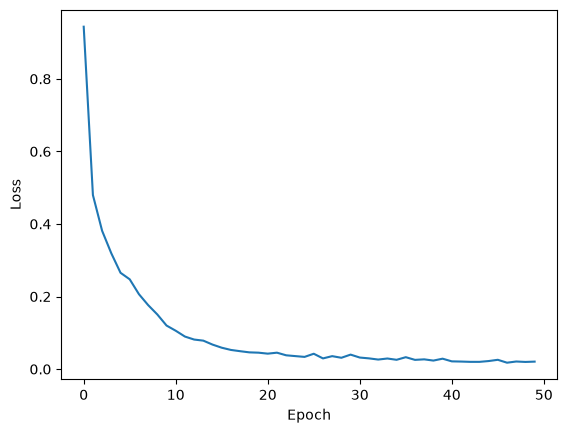

In [113]:
sns.lineplot(
    x=range(len(history.history["loss"])), 
    y=history.history["loss"]
)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [114]:
print(history.history.keys()) 

dict_keys(['accuracy', 'loss'])


In [115]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"loss: {loss:.2%},\naccuracy: {accuracy:.2%}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.9667 - loss: 0.2026
loss: 20.26%,
accuracy: 96.67%


In [116]:
y_pred = np.argmax(model.predict(X_test), axis= 1)
y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


array([2, 2, 2, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 2, 2, 1, 1, 0, 1, 2,
       1, 2, 0, 1, 2, 1, 0, 2])

In [117]:
print(y_pred.shape)

(30,)


In [118]:
y_true = np.argmax(y_test, axis= 1)
y_true

array([2, 2, 2, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 2, 1, 2, 2, 1, 1, 0, 1, 2,
       1, 2, 0, 1, 2, 1, 0, 2])

In [121]:
print(y_true.shape) 
print((y_true == y_pred).sum()) 

(30,)
29


In [122]:
cm = confusion_matrix(y_true, y_pred)

In [123]:
cm

array([[10,  0,  0],
       [ 0, 10,  0],
       [ 0,  1,  9]])

In [124]:
print(cm.trace())

29


29 / 30

In [125]:
accuracy_score(y_true, y_pred)

0.9666666666666667

In [126]:
recall_score(y_true, y_pred, average = "weighted")

0.9666666666666667

In [127]:
recall_score(y_true, y_pred, average=None)

array([1. , 1. , 0.9])

In [128]:
f1_score(y_true, y_pred, average = "macro")

0.9665831244778613

In [129]:
f1_score(y_true, y_pred, average=None)

array([1.        , 0.95238095, 0.94736842])

In [131]:
cat_array[np.argmax(model.predict(
    np.array([[4.7,3.2,1.3,0.2]])
))]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


'Iris-virginica'

In [ ]:
sample = np.array([[4.7, 3.2, 1.3, 0.2]])
sample_scaled = scaler.transform(sample)

cat_array[np.argmax(model.predict(sample_scaled))]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


'Iris-setosa'

In [133]:
print(sample_scaled)

[[-1.38535265  0.33784833 -1.39813811 -1.31297673]]


In [134]:
model.save("../data/iris_classifier.keras")

In [135]:
import pickle # or joblib

In [136]:
to_package = {
    "scaler": scaler,
    "encoder": onehot_encoder,
    "model": model
}

with open ("../data/iris_classifier.pkl", "wb") as file:
    pickle.dump(to_package, file)